In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Fetch TSLA data and IMMEDIATELY drop NaNs
tsla = yf.download('TSLA', start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
tsla = tsla.dropna() # This removes any holidays/missing days

# 2. Split into Train (80%) and Test (20%)
train_size = int(len(tsla) * 0.8)
train, test = tsla.iloc[:train_size], tsla.iloc[train_size:]

print(f"Total cleaned days: {len(tsla)}")
print(f"Training days: {len(train)}, Testing days: {len(test)}")

[*********************100%***********************]  1 of 1 completed

Total cleaned days: 2516
Training days: 2012, Testing days: 504


Finding optimal ARIMA parameters... (this might take a moment)


c:\Users\DELL 7020\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\DELL 7020\Desktop\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



ARIMA Results:
MAE: 110.99
RMSE: 125.59


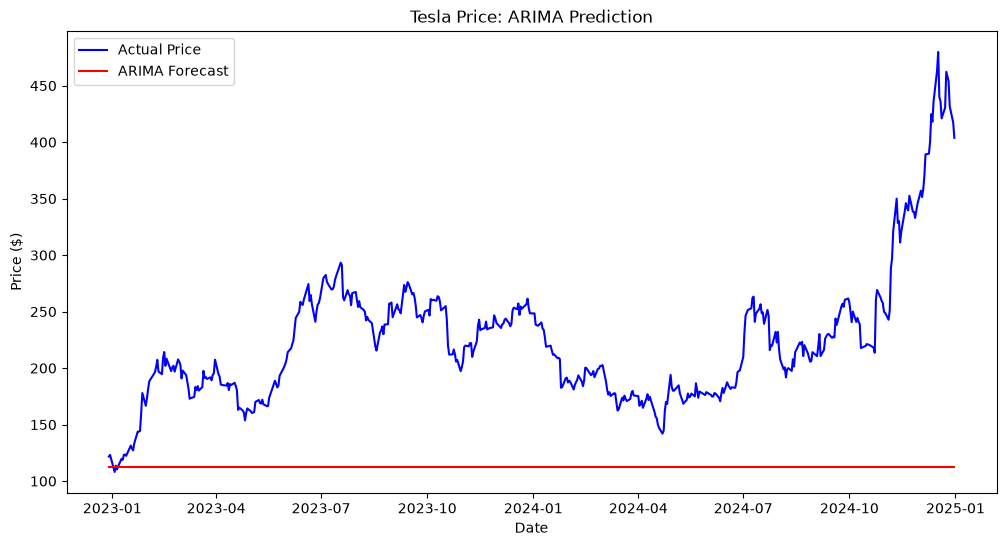

In [ ]:
# 3. Auto-ARIMA
print("Finding optimal ARIMA parameters... (this might take a moment)")
model_arima_fit = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore')

# 4. Generate Forecast
forecast_values = model_arima_fit.predict(n_periods=len(test))

actual_1d = np.array(test).flatten()
predicted_1d = np.array(forecast_values).flatten()

comparison = pd.DataFrame({
    'actual': actual_1d,
    'predicted': predicted_1d
}, index=test.index)

# 6. Remove any row that contains a NaN
comparison = comparison.dropna()

# 7. Evaluate ARIMA
rmse_arima = np.sqrt(mean_squared_error(comparison['actual'], comparison['predicted']))
mae_arima = mean_absolute_error(comparison['actual'], comparison['predicted'])

print(f"\nARIMA Results:")
print(f"MAE: {mae_arima:.2f}")
print(f"RMSE: {rmse_arima:.2f}")

# 8. Plot
plt.figure(figsize=(12,6))
plt.plot(comparison['actual'], label='Actual Price', color='blue')
plt.plot(comparison['predicted'], label='ARIMA Forecast', color='red')
plt.title('Tesla Price: ARIMA Prediction')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 6. Scaling for LSTM
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(tsla.values.reshape(-1, 1))

# 7. Create Sequence Data
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# Split sequences into train/test
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# 8. Build and Train LSTM
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=5, batch_size=32)

# 9. LSTM Prediction
lstm_preds = model.predict(X_test)
lstm_preds = scaler.inverse_transform(lstm_preds)
actual_test = scaler.inverse_transform(y_test.reshape(-1,1))

# 10. Evaluate LSTM
rmse_lstm = np.sqrt(mean_squared_error(actual_test, lstm_preds))
print(f"LSTM RMSE: {rmse_lstm:.2f}")

c:\Users\DELL 7020\Desktop\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0059
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0018
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0016
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0015
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0012
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
LSTM RMSE: 25.92


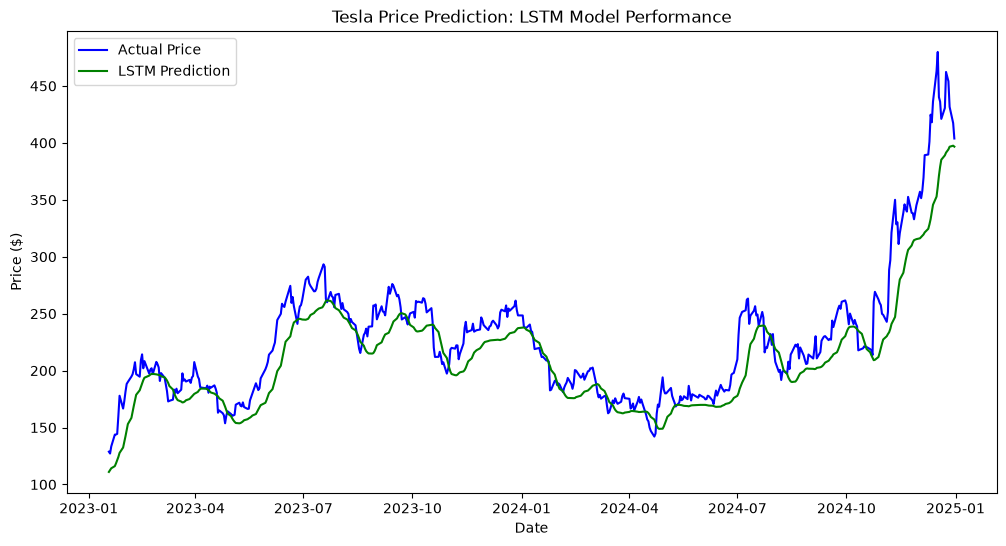

In [12]:
# Create a DataFrame for comparison
lstm_comparison = pd.DataFrame({
    'Actual': actual_test.flatten(),
    'Predicted': lstm_preds.flatten()
}, index=tsla.index[split+60:]) # Aligns with the test window

# Plot LSTM Results
plt.figure(figsize=(12,6))
plt.plot(lstm_comparison['Actual'], label='Actual Price', color='blue')
plt.plot(lstm_comparison['Predicted'], label='LSTM Prediction', color='green')
plt.title('Tesla Price Prediction: LSTM Model Performance')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()